In [1]:
import numpy as np
import pandas as pd
import os
import sys
import glob
import torch.nn as nn
from transformers import AutoConfig
from safetensors.torch import load_file  # comes with HF if safetensors installed
from sklearn.metrics import classification_report, recall_score
import tqdm
import re
import ast
from typing import List
import torch
import matplotlib.pyplot as plt
os.chdir("/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis")
sys.path.append("../../benchmark")
import test_base
from sentence_splitter import split_text_into_sentences
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from BERT_classifier.Classify_report_with_BERT import tf_idf

# Test using a BERT-Classification Model trained on paragraphs to classify an entire report.

**Function:** pdf -> NACE Class

## Load Data

In [2]:
dataset_path = "data/datasets/german_annual_reports"
dataset_path = "data/datasets/stoxx_600_extended"
dataset_path = "data/datasets/reports_subset_from_full_data_1"
dataset_path = "data/datasets/reports_subset_from_full_data_3"
dataset_path = "data/datasets/stoxx_600"

In [3]:
over_view_df_path = os.path.join(dataset_path, os.path.basename(dataset_path) + "_overview.csv")

dataset_path_texts = os.path.join(dataset_path, "TXTs")

dataset_name = os.path.basename(dataset_path)

In [4]:
cos_sim_path = "results/dataset__reports_subset_from_full_data_3_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1"
cos_sim_report_paths = glob.glob(cos_sim_path + "/*/*.csv")
len(cos_sim_report_paths)

813

In [5]:
results_path = "results/BERT_classification/dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/2_dataset__reports_subset_from_full_data_1_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_0_1__dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_2_1__with_relevancy__dataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_2_2__desc_pages__with_relevancy__dataset__stoxx_600_sentence_len_6__nace_level_1"
reports_results = glob.glob(results_path+ "/*/*.csv")
len(reports_results)

61

In [6]:
nace_classes = pd.read_csv(over_view_df_path, index_col=0, sep=";")
nace_classes.head()

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report,description_page
483,3i Group plc,III-GB,III-GB,701.210162,1276.962137,NaN,66.30,K,NaN,NaN
354,A.P. Moller - Maersk A/S Class B,MAERSK.B-DK,MAERSK.B-DK,77568.022858,47226.219381,51288.2262335699,50.20,H,NaN,NaN
275,A2A S.p.A.,A2A-IT,A2A-IT,22938.000000,14492.000000,NaN,35.11,D,NaN,NaN
107,AAK AB,AAK-SE,AAK-SE,4741.086317,4010.433824,3939.34280627966,10.89,C,AAK AB1.pdf,3
122,Aalberts N.V.,AALB-NL,AALB-NL,3230.000000,3324.000000,3148.6,25.93,C,Aalberts N.V.1.pdf,NaN


In [7]:
report_to_nace_class = nace_classes.dropna(subset=["Report"]).set_index('Report').to_dict()["NACE"]
report_to_nace_class = {report[0][:-4] + ".txt": report[1] for report in report_to_nace_class.items()}
len(report_to_nace_class)

291

In [8]:
reports_path = glob.glob(os.path.join(dataset_path_texts, "*.txt"))
len(reports_path)

263

## Define Aggregation methods

In [9]:
def softmax(x):
    e = np.exp(x - np.max(x))   # subtract max for numerical stability
    return e / e.sum()

In [10]:
def majority_vote(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:
    
    df.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df.loc[:,"max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]
    evaluation = (df["max_class_sim"].value_counts() / len(df)).sort_values(ascending=False).to_dict()

    return evaluation

In [11]:
def confidence_weighted_voting(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:

    df.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df.loc[:,"max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]
    evaluation = (df.groupby("max_class_sim")["max_sim"].sum().sort_values(ascending=False)/len(df)).to_dict()

    return evaluation

In [12]:
def logit_stacking(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:

    df.loc[:,"max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]

    stacked = df[scores].sum(0)
    
    evaluation = stacked.to_dict()

    return evaluation

In [13]:
def max_class_voting(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:

    df.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df.loc[:,"max_sim"] = df[scores].max(1)
    
    max_sim = df["max_sim"].max()
    res_class = df[df["max_sim"] == max_sim].sum(0)[scores]

    return res_class.to_dict()

In [14]:
# train_df = pd.read_csv("data/training_data/dataset_reports_subset_from_full_data_1__sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__2nd_approach__nace_level_1__cos_thres_0.4/full_data.csv")

# training_reports = train_df["text"].to_list()

# #Build TF-IDF model on all sentences from the training corpus
# tfidf_vectorizer = tf_idf.build_tfidf_model(training_reports)

In [15]:
def logit_stacking_conformal_prediction(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> set:

    df.loc[:,"max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]

    stacked = df[scores].sum(0)

    evaluation = stacked.to_dict()
    
    return evaluation

In [16]:
def tf_idf_weighted(df: pd.DataFrame, scores: list, threshold: float = 0, df_full: pd.DataFrame = None, k = 10) -> dict:
    shortened, ranked = tf_idf.select_top_sentences(
        report_paragraphs=df_full["Sentences"].to_list(),
        vectorizer=tfidf_vectorizer,
        max_words=2000
    )
    df_full = df_full.iloc[np.array(ranked)[:,2][:k]]
    
    #print(len(df_full))

    evaluation = logit_stacking(df_full.copy(), scores, threshold)

    return evaluation  

In [17]:
def only_use_paragraphs_with_large_cos_sim(df: pd.DataFrame, scores: list, threshold: float = 0, df_full: pd.DataFrame = None, df_cos_sim: pd.DataFrame = None, cos_sim_threshold = 0.4) -> dict:
        
    # apply threshold 
    df_cos_sim_scores = [column for column in df_cos_sim.columns if "Scores" in column]
    df_cos_sim.loc[:,"max_sim"] = df_cos_sim[df_cos_sim_scores].max(1)
    df_cos_sim["use_for_classification"] = df_cos_sim["max_sim"] > cos_sim_threshold

    # join into df_eval (BERT Classification)

    df_merged = pd.merge(df_full, df_cos_sim[["Sentences", "use_for_classification"]], on = "Sentences")
    df_merged = df_merged[df_merged["use_for_classification"]]

    scores = df.columns
    df_merged[scores] = df_merged[scores].apply(softmax, axis=1)
    df_softmax = df_merged[scores]

    evaluation = logit_stacking(df_softmax.copy(), scores, threshold)

    return evaluation  

In [18]:
def prefilter_binary(df: pd.DataFrame, scores: list, threshold: float = 0, df_full: pd.DataFrame = None, threshold_relevancy: float = 0.5, **kwargs) -> dict:

    # apply threshold
    #print(df_full.columns)

    df_full["is_explanation"] = df_full["Relevancy_sig"] > threshold_relevancy

    df_full = df_full[df_full["is_explanation"]]

    df_full.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df_full[scores], 1)]

    #print("\n".join(df_full["Sentences"].to_list()))
    #print(df_full[["Sentences", "max_class_sim"]])
    
    evaluation = logit_stacking(df_full[scores].copy(), scores, threshold)

    return evaluation  

## Define Metrics

In [19]:
def mean_reciprocal_rank(position_levels):
    """
    Compute Mean Reciprocal Rank (MRR)
    position_levels: list or array of integer ranks (0 = correct, 1 = 2nd, ...)
    """
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

def recall_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


def precision_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0


def accuracy_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    return np.mean(y_true_bin == y_pred_bin)


def f1_score(y_true, y_pred):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    return (2 * p * r) / (p + r) if (p + r) > 0 else 0.0


def mean_reciprocal_rank(position_levels):
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

def top3_acc(position_levels): 
    return np.mean(position_levels < 3)

## Test the aggregation methods

In [20]:
# for the cos sim approach, load cos_sim csvs

for results_path in reports_results:
    n = os.path.basename(results_path).replace("_classifications.csv", "")
    if os.path.exists(os.path.join(cos_sim_path, n, n + "_long.csv")): 
        df_cos_sim = pd.read_csv(os.path.join(cos_sim_path, n, n + "_long.csv"))
        df_eval = pd.read_csv(results_path, index_col=0)

sentence_in_cos_sim = []
for i in range(len(df_eval)): 
    sentence_in_cos_sim.append(df_eval["Sentences"][i] in df_cos_sim["Sentences"].to_list())
    #print(df_cos_sim["Sentences"].to_list().index(df_eval["Sentences"][i]))
np.all(sentence_in_cos_sim)
df_cos_sim.head()
df_eval.head()

,A,H,L,D,F,I,G,C,M,P,Q,J,B,K,E,classification,max_class_sim,Sentences,Relevancy_sig,Relevancy_over_0_5
0,-0.324260,-0.462188,-0.864714,0.084200,0.203109,-1.368828,-0.177058,1.388462,1.738068,1.009392,-0.561093,-0.721321,-0.215632,-1.355399,-0.496282,"{'M': 0.27945959770810525, 'C': 0.197009472667...",M,the pace of digitalization in norwegian indust...,0.905401,True
1,-0.480778,-1.639547,-0.353876,-1.222881,-0.487955,-1.181666,-0.533090,-1.060347,4.325628,1.409998,1.004814,-0.396301,-0.591562,-1.609054,-1.463307,"{'M': 0.8615820375512517, 'P': 0.0466718244854...",M,we connect the real and the digital worlds in ...,0.950727,True
2,-0.185541,1.128816,-1.838951,1.100800,0.556508,-1.765191,-0.233922,4.357296,-1.149206,-0.726225,-1.947487,-1.403825,0.299806,-0.433843,1.363320,"{'C': 0.8220815091246113, 'E': 0.0411763241028...",C,products and solutions for automating discrete...,0.952197,True
3,-0.528476,-1.754984,-0.136626,-1.315279,-0.435624,-1.104225,-0.546153,-1.281728,4.458426,1.260367,1.254733,-0.494096,-0.618889,-1.540861,-1.521650,"{'M': 0.8748487241510459, 'P': 0.0357300354528...",M,digital industries gained several new customer...,0.932148,True
4,-0.448986,0.757062,-1.848797,1.454964,0.715631,-1.877201,-0.510235,4.325224,-0.975242,-0.462833,-1.815393,-1.382239,0.382096,-0.716655,1.496738,"{'C': 0.8089347124942723, 'E': 0.0478098768389...",C,digital industries designed a digital twin of ...,0.893869,True


In [21]:
ckpt_path = "results/BERT_models/NACE_classification/037_results__data_approach_3__desc_lvl_level_1_dataset_2__num_layers_1__cos_thres_0.5bert-base-uncased__train_full_model__some_labels__only_labels/checkpoint-743"
tokenizer = AutoTokenizer.from_pretrained(ckpt_path) 

t = tokenizer("""Household insurance teams
support customers impacted
by extreme weather
This year, a number of extreme weather events devastated
communities across the world. At the start of 2022, we saw
catastrophic storms and flooding hit areas of the UK. We took
a proactive approach to protecting our customers during
this time. Before the storms made landfall, our Household
insurance team contacted all customers who held policies
in areas of risk. We explained the risks of possible flooding
and asked if any help was required. Throughout the period,
we continued to monitor flood warnings and added
customers to our contact list if their risk exposure were
to increase.
During storms Dudley, Eunice and Franklin, we made sure that
enough support was in place for what we knew would be an
influx of customers contacting us. This included enlisting help
from employees across the business, including our offices in
Delhi, to manage the increased number of calls. We made
calling to make a claim easy with online banners and
increased the number of employees on phones and webchat
to assist with questions from customers.
Similarly, in Gironde, southern France, we saw wildfires cause
damage across the region. Our French Household business
quickly contacted customers affected by these fires and
made sure they were given quick access to alternative
accommodation in cases where they were displaced.""", return_tensors="pt", truncation=True)

In [22]:
t["input_ids"].shape[1]

255

In [23]:
from sklearn.model_selection import train_test_split

test_indices, calibration_indices = train_test_split(np.arange(len(reports_results)), test_size=0.5, random_state=42)

In [32]:
class_evals = []

results = []

#for agg_func in [only_use_paragraphs_with_large_cos_sim, majority_vote, confidence_weighted_voting, logit_stacking, tf_idf_weighted]: 
for agg_func in [logit_stacking]: 
    
    print("--------")
    print()
    print(agg_func.__name__)
    print()
    print("--------")
    k = 30
    conf = 0.0
    # for cos_sim_threshold in [0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65]:
    # for threshold_relevancy in [0.2,0.3,0.4,0.5,0.6,0.7]:
    for threshold_relevancy in [0.7]:
    # for conf in [0.9]:
    # for k in [5,10,20,30,40,50]:
    # for k in [30]:
        level = 1
        recording = [] 

        #if path_nace_code_descriptions is None: 
        path_nace_code_descriptions = "data/NACE_Rev2_Structure_Explanatory_Notes_EN__1_.tsv"
            
        df_nace_codes_descriptions = pd.read_csv(path_nace_code_descriptions, sep="\t")

        for results_path in tqdm.tqdm(np.array(reports_results)[calibration_indices]): 

            report_name = os.path.basename(results_path.split("/")[-2])
            label = report_to_nace_class.get(report_name)

            level_1_label = test_base.get_all_level(label)[1]

            df_eval = pd.read_csv(results_path, index_col=0)
            
            # ONLY USE TOP K
            df_eval = df_eval
            
            scores = df_eval.columns.drop(["Sentences", "Relevancy_sig", "Relevancy_over_0_5", 'classification', 'max_class_sim'])

            df_eval[scores] = df_eval[scores].apply(softmax, axis=1)
            df_softmax = df_eval[scores].copy()
            
            class_eval_dict = agg_func(
                    df_softmax, scores, threshold=conf, df_full=df_eval.copy(), k = k, threshold_relevancy =threshold_relevancy
                )
            class_eval_dict["right_class"] = level_1_label

            class_evals.append(class_eval_dict)
            

--------

logit_stacking

--------


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31/31 [00:00<00:00, 101.20it/s]


In [33]:
alpha = 0.5

In [34]:
df_class_evals = pd.DataFrame(class_evals)
scores = df_class_evals.columns.drop("right_class")
df_class_evals[scores] = df_class_evals[scores].apply(softmax, 1)
df_class_evals

,A,H,L,D,F,I,G,C,M,P,Q,J,B,K,E,right_class
0,4.802169e-02,0.048630,4.688047e-02,4.737486e-02,4.638244e-02,4.686910e-02,2.865698e-01,0.104389,4.585003e-02,4.589825e-02,4.581066e-02,4.587759e-02,4.626486e-02,4.746044e-02,4.772056e-02,C
1,2.387932e-03,0.002322,2.918719e-03,2.305215e-03,2.704290e-03,2.345661e-03,2.725183e-03,0.002313,3.477281e-01,2.836608e-03,6.824777e-03,2.395963e-03,2.485373e-03,6.154065e-01,2.301235e-03,F
2,2.960178e-02,0.544422,2.767730e-02,2.953509e-02,3.775892e-02,2.728022e-02,3.522792e-02,0.039854,6.459375e-02,2.846698e-02,2.702394e-02,2.669297e-02,2.674619e-02,2.818402e-02,2.693426e-02,C
3,9.183487e-04,0.000883,6.375114e-03,8.520563e-04,9.505479e-04,8.715452e-04,4.912032e-03,0.000861,6.501077e-03,9.307540e-04,1.054997e-03,8.827757e-04,8.984441e-04,9.722650e-01,8.436660e-04,K
4,8.497683e-03,0.007732,1.143657e-02,7.272296e-03,8.148192e-03,7.485626e-03,9.389951e-02,0.016090,5.380814e-02,8.404818e-03,8.745620e-03,1.022147e-02,3.746921e-01,3.754486e-01,8.117058e-03,B
5,1.962692e-02,0.017810,2.418414e-02,1.749552e-02,1.888875e-02,1.879752e-02,4.508574e-02,0.017760,5.500465e-01,2.091616e-02,1.432076e-01,1.961160e-02,1.796337e-02,5.115032e-02,1.745587e-02,C
6,6.547045e-02,0.062947,6.368241e-02,6.265567e-02,6.353012e-02,6.364310e-02,7.024431e-02,0.063373,6.472200e-02,6.337823e-02,8.795115e-02,6.935750e-02,6.468900e-02,7.079252e-02,6.356343e-02,C
7,2.955992e-06,0.000003,3.028515e-06,2.887528e-06,2.982080e-06,2.911441e-06,7.193132e-06,0.000003,2.870326e-06,2.864326e-06,2.902439e-06,2.900244e-06,2.952233e-06,9.999548e-01,2.872351e-06,K
8,1.314307e-03,0.001513,1.383855e-03,8.012201e-03,1.379822e-03,1.197390e-03,5.387001e-03,0.049652,1.384632e-03,1.204480e-03,1.263431e-03,1.210820e-03,1.727526e-03,9.189292e-01,4.440836e-03,C
9,6.010322e-02,0.060138,6.024626e-02,6.006893e-02,6.033124e-02,6.008101e-02,6.091208e-02,0.060086,6.005312e-02,6.004267e-02,6.012565e-02,6.009531e-02,6.025457e-02,1.574062e-01,6.005656e-02,K


In [35]:
df_class_evals = df_class_evals[df_class_evals["right_class"] != "N"]
df_class_evals = df_class_evals[df_class_evals["right_class"] != "S"]

In [38]:
prob_right_class = [row[row["right_class"]] for _, row in df_class_evals.iterrows()]
non_conformity_scores = 1 - np.array(prob_right_class)
non_conformity_scores

array([8.95611134e-01, 9.97295710e-01, 9.60145837e-01, 2.77349963e-02,
       6.25307875e-01, 9.82240085e-01, 9.36626867e-01, 4.52394123e-05,
       9.50348494e-01, 8.42593825e-01, 9.84446932e-01, 8.90389441e-01,
       6.02825966e-01, 8.41802348e-01, 2.68032697e-01, 9.63356309e-01,
       9.99993944e-01, 2.08603725e-03, 1.91001532e-02, 9.90499575e-01,
       9.58613404e-01, 9.99267665e-01, 2.29396702e-01, 8.85752985e-01,
       2.50679012e-01, 8.80151898e-03, 9.92684673e-01, 5.09511929e-02])

(array([12.,  5.,  0.,  2.,  0.,  0.,  0.,  3.,  0.,  6.]),
 array([6.05571955e-06, 1.00000926e-01, 1.99995797e-01, 2.99990667e-01,
        3.99985538e-01, 4.99980408e-01, 5.99975279e-01, 6.99970149e-01,
        7.99965020e-01, 8.99959890e-01, 9.99954761e-01]),
 <BarContainer object of 10 artists>)

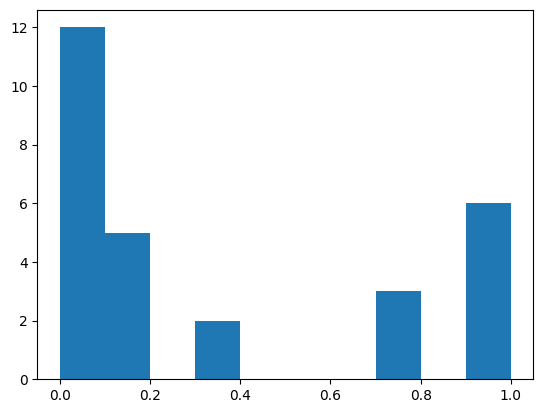

In [39]:
plt.hist(prob_right_class)

In [40]:
for prob in prob_right_class: 
    print(prob)

0.10438886573749079
0.002704290145485542
0.039854162767426315
0.972265003709698
0.3746921253568625
0.01775991464697815
0.06337313319476061
0.9999547605877102
0.04965150623120022
0.15740617530528325
0.015553068007599001
0.10961055859059712
0.3971740339446802
0.15819765190820503
0.7319673025956139
0.036643690997866525
6.05571954677423e-06
0.9979139627539304
0.9808998468245556
0.009500425493233997
0.041386596455282164
0.0007323352164862405
0.7706032977514902
0.11424701533683601
0.749320987921909
0.9911984810226382
0.0073153266990413175
0.9490488071464999


In [37]:
q = np.quantile(non_conformity_scores, 1-alpha)
q

0.8880712130362834

## Predict

In [30]:
class_evals = []

results = []

#for agg_func in [only_use_paragraphs_with_large_cos_sim, majority_vote, confidence_weighted_voting, logit_stacking, tf_idf_weighted]: 
for agg_func in [logit_stacking]: 
    
    print("--------")
    print()
    print(agg_func.__name__)
    print()
    print("--------")
    k = 30
    conf = 0.0
    # for cos_sim_threshold in [0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65]:
    # for threshold_relevancy in [0.2,0.3,0.4,0.5,0.6,0.7]:
    for threshold_relevancy in [0.7]:
    # for conf in [0.9]:
    # for k in [5,10,20,30,40,50]:
    # for k in [30]:
        level = 1
        recording = [] 

        #if path_nace_code_descriptions is None: 
        path_nace_code_descriptions = "data/NACE_Rev2_Structure_Explanatory_Notes_EN__1_.tsv"
            
        df_nace_codes_descriptions = pd.read_csv(path_nace_code_descriptions, sep="\t")

        for results_path in tqdm.tqdm(np.array(reports_results)[test_indices]): 

            report_name = os.path.basename(results_path.split("/")[-2])
            label = report_to_nace_class.get(report_name)

            level_1_label = test_base.get_all_level(label)[1]

            df_eval = pd.read_csv(results_path, index_col=0)
            
            # ONLY USE TOP K
            df_eval = df_eval
            
            scores = df_eval.columns.drop(["Sentences", "Relevancy_sig", "Relevancy_over_0_5", 'classification', 'max_class_sim'])

            df_eval[scores] = df_eval[scores].apply(softmax, axis=1)
            df_softmax = df_eval[scores].copy()
            
            class_eval_dict = agg_func(
                    df_softmax, scores, threshold=conf, df_full=df_eval.copy(), k = k, threshold_relevancy =threshold_relevancy
                )
            class_eval_dict

            # Convert dictionary values to float and apply softmax
            classification_dict = class_eval_dict
            classification_dict = {key: float(value) for key, value in classification_dict.items()}
            softmax_values = softmax(list(classification_dict.values()))
            classification_dict = dict(zip(classification_dict.keys(), softmax_values))
            
            non_conformity_score = {key: 1-value for key, value in classification_dict.items()}

            prediction_set = {key: value for key, value in non_conformity_score.items() if value <= q}

            print(classification_dict)
            print(prediction_set)
            print()
            print()

--------

logit_stacking

--------


 27%|███████████████████████████████████████████████▍                                                                                                                                  | 8/30 [00:00<00:00, 76.10it/s]

{'A': 0.019375623644677962, 'H': 0.019734727395685877, 'L': 0.019506244998878767, 'D': 0.6495785791474948, 'F': 0.067314616906017, 'I': 0.01931488846803361, 'G': 0.019380750645038004, 'C': 0.021369180631378454, 'M': 0.04657180596703991, 'P': 0.02001993048915491, 'Q': 0.01989470743208981, 'J': 0.019307144599674687, 'B': 0.01949872822979111, 'K': 0.019336564515169644, 'E': 0.01979650692987536}
{'A': 0.9806243763553221, 'H': 0.9802652726043142, 'L': 0.9804937550011212, 'D': 0.35042142085250516, 'F': 0.932685383093983, 'I': 0.9806851115319664, 'G': 0.980619249354962, 'C': 0.9786308193686215, 'M': 0.9534281940329601, 'P': 0.979980069510845, 'Q': 0.9801052925679102, 'J': 0.9806928554003254, 'B': 0.9805012717702088, 'K': 0.9806634354848304, 'E': 0.9802034930701247}


{'A': 0.045296235078809394, 'H': 0.04519291960651387, 'L': 0.04567218035498878, 'D': 0.04512432008787092, 'F': 0.046217361291660757, 'I': 0.04529884005535216, 'G': 0.04636851105824331, 'C': 0.04520254152463969, 'M': 0.08084809608

 77%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                                         | 23/30 [00:00<00:00, 117.65it/s]

{'A': 0.0001766129674916843, 'H': 0.00017472898947350007, 'L': 0.00019550422998525387, 'D': 0.00017264294939255148, 'F': 0.00018300521990605737, 'I': 0.0001738930827883975, 'G': 0.00022369082177856612, 'C': 0.00017321364017975786, 'M': 0.00025189979031388214, 'P': 0.00017489515683814926, 'Q': 0.00021740756516618919, 'J': 0.00017618053502675265, 'B': 0.00018160098272786924, 'K': 0.9973522007955563, 'E': 0.00017252327337511096}
{'K': 0.0026477992044436904}


{'A': 0.10847511053722018, 'H': 0.023769440815321605, 'L': 0.02267727817899983, 'D': 0.02174091782805767, 'F': 0.021087715659778798, 'I': 0.0348040586812189, 'G': 0.5635469561712445, 'C': 0.02496707425038952, 'M': 0.020999430826058738, 'P': 0.02097710930219767, 'Q': 0.021074675183238124, 'J': 0.021244218371015543, 'B': 0.021284170684342626, 'K': 0.022565881494562647, 'E': 0.05078596201635341}
{'A': 0.8915248894627799, 'H': 0.9762305591846784, 'L': 0.9773227218210002, 'D': 0.9782590821719424, 'F': 0.9789122843402212, 'I': 0.9651959413

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 115.74it/s]

{'A': 3.4701640088209695e-05, 'H': 8.165291128785085e-05, 'L': 5.737994680573184e-05, 'D': 3.0236951140128684e-05, 'F': 9.094518288016776e-05, 'I': 0.00011580352432461698, 'G': 0.0001300612061551534, 'C': 3.232600618722652e-05, 'M': 0.10734331222424541, 'P': 4.285669654210976e-05, 'Q': 7.4949771964756e-05, 'J': 3.583453886036651e-05, 'B': 3.594276671731264e-05, 'K': 0.8917683396408507, 'E': 0.000125656991950308}
{'M': 0.8926566877757546, 'K': 0.10823166035914933}


{'A': 0.010938182540648825, 'H': 0.007962285349329247, 'L': 0.010096824706737461, 'D': 0.005780582746900204, 'F': 0.9086459128516703, 'I': 0.00519284691622018, 'G': 0.009838328728194266, 'C': 0.006160139833188726, 'M': 0.004990233691772521, 'P': 0.004384259419449129, 'Q': 0.00472562170924608, 'J': 0.0047374080423601556, 'B': 0.00480211756612272, 'K': 0.007195007957788022, 'E': 0.00455024794037209}
{'A': 0.9890618174593512, 'H': 0.9920377146506707, 'L': 0.9899031752932625, 'F': 0.09135408714832971, 'G': 0.9901616712718058, 'C

In [31]:
prediction_set

{'A': 0.9923056056215876,
 'H': 0.23212019942778228,
 'L': 0.992262360388713,
 'D': 0.8798939043095124,
 'F': 0.9919295408342442,
 'I': 0.9923184154294644,
 'G': 0.9920121161065489,
 'C': 0.9900484715352693,
 'M': 0.9833224879021033,
 'P': 0.992286533043148,
 'Q': 0.9920906694717015,
 'J': 0.9924403230510703,
 'B': 0.9924208951327634,
 'K': 0.9924005134644482,
 'E': 0.992147964281643}